In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv(r"C:\Users\prafu\OneDrive\Documents\Zomato_KPT\zomato_kpt_feature_engineered.csv")


In [3]:
df.shape

(550502, 18)

Dataset shape: (550502, 19)

================ MODEL BENCHMARK ================

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1396
[LightGBM] [Info] Number of data points in the train set: 440401, number of used features: 18
[LightGBM] [Info] Start training from score 32.368949
LightGBM -> MAE: 2.005 | RMSE: 3.755 | R2: 0.8688
--------------------------------------------------
Training XGBoost...
XGBoost -> MAE: 2.036 | RMSE: 3.701 | R2: 0.8726
--------------------------------------------------
Training CatBoost...
CatBoost -> MAE: 1.995 | RMSE: 3.642 | R2: 0.8766
--------------------------------------------------
Training RandomForest...
RandomForest -> MAE: 2.093 | RMSE: 3.729 | R2: 0.8706
--------------------------------------------------
Training DecisionT

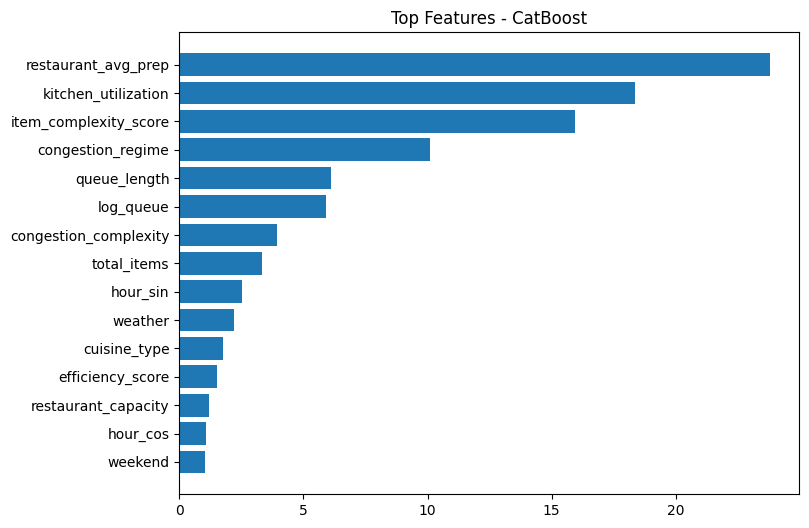


Best Model: CatBoost
Model saved successfully.


In [4]:
# ADD CONGESTION REGIME FEATURE

df["congestion_regime"] = pd.cut(
    df["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3]
).astype(float).fillna(-1).astype(int)

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Dataset shape:", df.shape)

# TIME BASED TRAIN TEST SPLIT (80-20)

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# Smooth congestion weights (for boosting models only)
train_weights = 1 + (X_train["kitchen_utilization"] ** 2) * 2

# DEFINE MODELS

models = {

    "LightGBM": lgb.LGBMRegressor(
        objective="huber",
        alpha=0.9,
        n_estimators=1200,
        learning_rate=0.04,
        num_leaves=64,
        max_depth=10,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=1200,
        learning_rate=0.04,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=1200,
        learning_rate=0.04,
        depth=8,
        verbose=0,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=14,
        n_jobs=-1,
        random_state=42
    ),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=14,
        min_samples_leaf=25,
        random_state=42
    ),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.001)
}

# TRAIN & BENCHMARK

results = []
best_mae = float("inf")
best_model = None
best_model_name = ""

print("\n================ MODEL BENCHMARK ================\n")

for name, model in models.items():

    print(f"Training {name}...")

    if name in ["LightGBM", "XGBoost", "CatBoost"]:
        model.fit(X_train, y_train, sample_weight=train_weights)
    else:
        model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    # Congestion-specific evaluation
    df_test = df.iloc[split_index:].copy()
    df_test["prediction"] = preds

    congestion_mask = df_test["kitchen_utilization"] > 0.8

    mae_cong = mean_absolute_error(
        df_test[congestion_mask]["prep_time"],
        df_test[congestion_mask]["prediction"]
    )

    mae_normal = mean_absolute_error(
        df_test[~congestion_mask]["prep_time"],
        df_test[~congestion_mask]["prediction"]
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAE_Congestion": mae_cong,
        "MAE_Normal": mae_normal
    })

    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_model_name = name

    print(f"{name} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.4f}")
    print("--------------------------------------------------")

results_df = pd.DataFrame(results).sort_values(by="MAE")

print("\n🏆 FINAL RANKING (Sorted by MAE)\n")
print(results_df)

# FEATURE IMPORTANCE (If Tree Model)

if hasattr(best_model, "feature_importances_"):

    importances = pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nTop 15 Features of Best Model:\n")
    print(importances.head(15))

    plt.figure(figsize=(8,6))
    plt.barh(importances["feature"][:15], importances["importance"][:15])
    plt.gca().invert_yaxis()
    plt.title(f"Top Features - {best_model_name}")
    plt.show()

# SAVE BEST MODEL

joblib.dump(best_model, f"best_model_{best_model_name}.pkl")

print(f"\nBest Model: {best_model_name}")
print("Model saved successfully.")

## Using Multi-Fold CV

In [6]:


df["congestion_regime"] = pd.cut(
    df["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3]
).astype(float).fillna(-1).astype(int)

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Dataset shape:", df.shape)

# HOLDOUT SPLIT (FINAL 20%)

split_index = int(len(df) * 0.8)

X_full_train = X.iloc[:split_index]
y_full_train = y.iloc[:split_index]

X_holdout = X.iloc[split_index:]
y_holdout = y.iloc[split_index:]

# DEFINE MODELS

models = {

    "LightGBM": lgb.LGBMRegressor(
        objective="huber",
        n_estimators=1200,
        learning_rate=0.04,
        num_leaves=64,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=1200,
        learning_rate=0.04,
        max_depth=8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=1200,
        learning_rate=0.04,
        depth=8,
        verbose=0,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=14,
        n_jobs=-1,
        random_state=42
    ),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=14,
        min_samples_leaf=25,
        random_state=42
    ),

    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001)
}

# TIMESERIES CROSS VALIDATION

tscv = TimeSeriesSplit(n_splits=5)

results = []

print("\n================ CROSS VALIDATION ================\n")

for name, model in models.items():

    mae_scores = []
    rmse_scores = []
    r2_scores = []

    print(f"\nRunning CV for {name}...")

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_full_train)):

        X_train = X_full_train.iloc[train_idx]
        X_val   = X_full_train.iloc[val_idx]

        y_train = y_full_train.iloc[train_idx]
        y_val   = y_full_train.iloc[val_idx]

        weights = 1 + (X_train["kitchen_utilization"] ** 2) * 2

        if name in ["LightGBM", "XGBoost", "CatBoost"]:
            model.fit(X_train, y_train, sample_weight=weights)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_val)

        mae_scores.append(mean_absolute_error(y_val, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))

        print(f"Fold {fold+1} MAE: {mae_scores[-1]:.3f}")

    results.append({
        "Model": name,
        "CV_MAE": np.mean(mae_scores),
        "CV_RMSE": np.mean(rmse_scores),
        "CV_R2": np.mean(r2_scores)
    })

results_df = pd.DataFrame(results).sort_values(by="CV_MAE")

print("\n🏆 CROSS VALIDATION RANKING\n")
print(results_df)

# TRAIN BEST MODEL ON FULL TRAIN DATA

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nTraining Best Model on Full Training Set: {best_model_name}")

full_weights = 1 + (X_full_train["kitchen_utilization"] ** 2) * 2

if best_model_name in ["LightGBM", "XGBoost", "CatBoost"]:
    best_model.fit(X_full_train, y_full_train, sample_weight=full_weights)
else:
    best_model.fit(X_full_train, y_full_train)

# FINAL HOLDOUT EVALUATION

holdout_preds = best_model.predict(X_holdout)

mae = mean_absolute_error(y_holdout, holdout_preds)
rmse = np.sqrt(mean_squared_error(y_holdout, holdout_preds))
r2 = r2_score(y_holdout, holdout_preds)

print("\n===== FINAL HOLDOUT PERFORMANCE =====")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2:", round(r2, 4))

# SAVE BEST MODEL

joblib.dump(best_model, f"best_model_{best_model_name}.pkl")
print("Best model saved successfully.")

Dataset shape: (550502, 19)

================ CROSS VALIDATION ================


Running CV for LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1297
[LightGBM] [Info] Number of data points in the train set: 73401, number of used features: 17
[LightGBM] [Info] Start training from score 29.918730
Fold 1 MAE: 2.098
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1398
[LightGBM] [Info] Number of data points in the train set: 146801, number of used features: 18
[LightGBM] [Info] Start training from score 33.027927
Fold 2 MAE: 2.002
[LightGBM] [Info] Auto-choosing row-wise

## FINAL MODEL WITH ALL SPECIFICATIONS 

Dataset shape: (550502, 19)

================ CROSS VALIDATION ================


Model: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1297
[LightGBM] [Info] Number of data points in the train set: 73401, number of used features: 17
[LightGBM] [Info] Start training from score 29.918730
  Fold 1 → MAE: 2.094 | RMSE: 4.054 | R2: 0.8553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1398
[LightGBM] [Info] Number of data points in the train set: 146801, number of used features: 18
[LightGBM] [Info] Start training from score 33.027927
  Fold 2 → MAE: 2.002 | RMSE: 3.682 | 

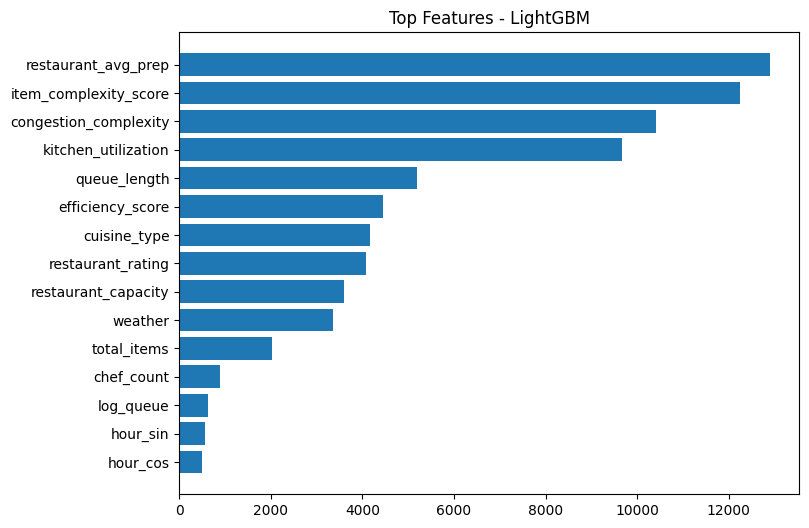


Model saved as best_model_LightGBM.pkl


In [7]:
import warnings

warnings.filterwarnings("ignore")

df["congestion_regime"] = pd.cut(
    df["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3]
).astype(float).fillna(-1).astype(int)

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Dataset shape:", df.shape)

# HOLDOUT SPLIT (FINAL 20%)

split_index = int(len(df) * 0.8)

X_train_full = X.iloc[:split_index]
y_train_full = y.iloc[:split_index]

X_holdout = X.iloc[split_index:]
y_holdout = y.iloc[split_index:]

# MODEL DEFINITIONS

models = {
    "LightGBM": lgb.LGBMRegressor(
        objective="huber",
        n_estimators=1200,
        learning_rate=0.04,
        num_leaves=64,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=1200,
        learning_rate=0.04,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=1200,
        learning_rate=0.04,
        depth=8,
        verbose=0,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=14,
        n_jobs=-1,
        random_state=42
    ),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=14,
        min_samples_leaf=25,
        random_state=42
    ),

    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001)
}

# TIMESERIES CROSS VALIDATION

tscv = TimeSeriesSplit(n_splits=5)
results = []

print("\n================ CROSS VALIDATION ================\n")

for name, model in models.items():

    mae_scores = []
    rmse_scores = []
    r2_scores = []

    print(f"\nModel: {name}")

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):

        X_train = X_train_full.iloc[train_idx]
        X_val   = X_train_full.iloc[val_idx]

        y_train = y_train_full.iloc[train_idx]
        y_val   = y_train_full.iloc[val_idx]

        weights = 1 + (X_train["kitchen_utilization"] ** 2) * 2

        if name in ["LightGBM", "XGBoost", "CatBoost"]:
            model.fit(X_train, y_train, sample_weight=weights)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_val)

        mae = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2 = r2_score(y_val, preds)

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        r2_scores.append(r2)

        print(f"  Fold {fold+1} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.4f}")

    print(f"  >> Mean MAE: {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")

    results.append({
        "Model": name,
        "CV_MAE_Mean": np.mean(mae_scores),
        "CV_MAE_Std": np.std(mae_scores),
        "CV_RMSE_Mean": np.mean(rmse_scores),
        "CV_R2_Mean": np.mean(r2_scores)
    })

# DISPLAY RANKING

results_df = pd.DataFrame(results).sort_values(by="CV_MAE_Mean")

print("\n================ MODEL RANKING ================\n")
print(results_df)

# Select best model
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_model = models[best_model_name]

print(f"\n🏆 BEST MODEL BASED ON LOWEST CV MAE: {best_model_name}")
print(f"CV MAE: {best_row['CV_MAE_Mean']:.4f}")

# TRAIN BEST MODEL ON FULL TRAINING SET

full_weights = 1 + (X_train_full["kitchen_utilization"] ** 2) * 2

if best_model_name in ["LightGBM", "XGBoost", "CatBoost"]:
    best_model.fit(X_train_full, y_train_full, sample_weight=full_weights)
else:
    best_model.fit(X_train_full, y_train_full)

# HOLDOUT EVALUATION

holdout_preds = best_model.predict(X_holdout)

mae = mean_absolute_error(y_holdout, holdout_preds)
rmse = np.sqrt(mean_squared_error(y_holdout, holdout_preds))
r2 = r2_score(y_holdout, holdout_preds)

print("\n================ FINAL HOLDOUT PERFORMANCE ================\n")
print(f"Model Used: {best_model_name}")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2:", round(r2, 4))

# CONGESTION-SPECIFIC EVALUATION

df_holdout = df.iloc[split_index:].copy()
df_holdout["prediction"] = holdout_preds

mask = df_holdout["kitchen_utilization"] > 0.8

mae_cong = mean_absolute_error(
    df_holdout[mask]["prep_time"],
    df_holdout[mask]["prediction"]
)

mae_normal = mean_absolute_error(
    df_holdout[~mask]["prep_time"],
    df_holdout[~mask]["prediction"]
)

print("\nMAE During Congestion:", round(mae_cong, 3))
print("MAE During Normal:", round(mae_normal, 3))

# FEATURE IMPORTANCE (IF SUPPORTED)

if hasattr(best_model, "feature_importances_"):

    importances = pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nTop 15 Important Features:\n")
    print(importances.head(15))

    plt.figure(figsize=(8,6))
    plt.barh(importances["feature"][:15], importances["importance"][:15])
    plt.gca().invert_yaxis()
    plt.title(f"Top Features - {best_model_name}")
    plt.show()

# SAVE BEST MODEL

joblib.dump(best_model, f"best_model_{best_model_name}.pkl")
print(f"\nModel saved as best_model_{best_model_name}.pkl")